# Ray Calculation

Current step as of Fri Aug 7: Seems to be a units issue or some scale problem for the IAT. Gets bigger instead of smaller

In [1]:
import numpy as np
from astropy import units as u

In [2]:
pwd

'/Users/ibehbehani/csm_pipeline'

In [3]:
import csv

csm_2d_density_list = []
with open("csm_2d_density.csv") as csvfile:
    reader = csv.reader(csvfile, quoting=csv.QUOTE_NONNUMERIC) # change contents to floats
    for row in reader: # each row is a list
        csm_2d_density_list.append(row)

In [4]:
csm_2d_density = np.array(csm_2d_density_list)


In [5]:
csm_2d_density[np.isnan(csm_2d_density)] = 0



In [6]:
csm_2d_density.shape

(1000, 1000)

In [7]:
print('max',np.max(csm_2d_density))
print('min',np.min(csm_2d_density))

max 0.00024578104746353477
min -0.0011468983518358195


In [8]:
# get ready to crop out all of the nan vals
center_x = 499
center_y = 499
pix_size_arcsec = 0.005*u.arcsec

In [9]:
from matplotlib import pyplot as plt

In [10]:
csm_2d_density[499,499]

np.float64(0.0)

Text(0, 0.5, '$\\Delta$ Dec (arc)')

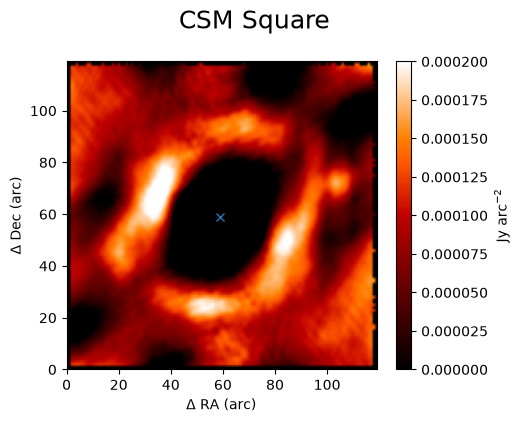

In [11]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

a=440
b=560

im = ax.pcolormesh(csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

# ax.set_xlim(a,b)
# ax.set_ylim(a,b)
ax.plot(center_x-a,center_y-a,'x')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [12]:
import sys

In [13]:
np.set_printoptions(threshold=sys.maxsize)

Text(0, 0.5, '$\\Delta$ Dec (arc)')

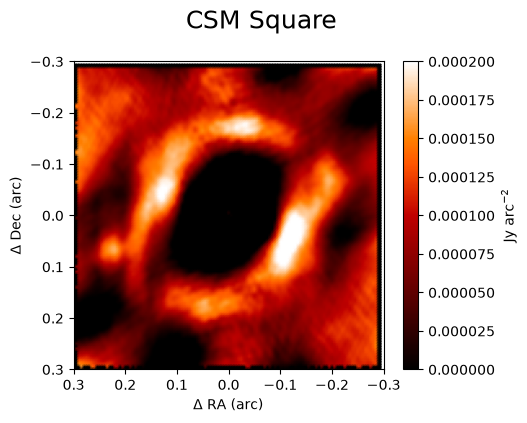

In [14]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis1[a:b],yaxis1[a:b],csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [15]:
from radial_interpolation import *

hello again


In [16]:
pix_size_arcsec

<Quantity 0.005 arcsec>

In [17]:
lines = 201
points = 200

In [18]:
#moving center for cropped image
center_interp = int(csm_2d_density[a:b,a:b].shape[0]/2-1)
center_interp

59

59 59 0.005 arcsec True


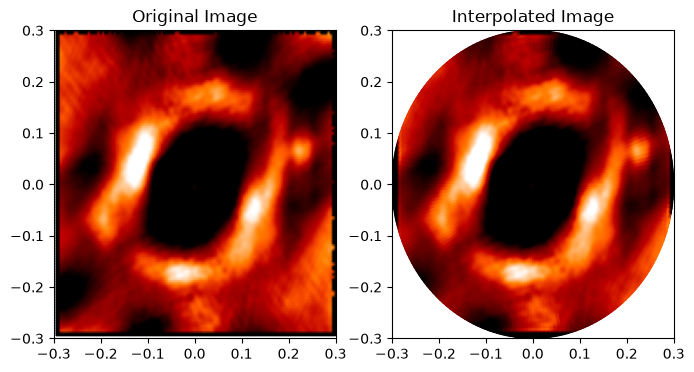

In [19]:
x_grid,y_grid,interp_csm = radial_interp(csm_2d_density[a:b,a:b], center_interp,center_interp,
              n_lines = lines, n_pts = points, pix_arc = pix_size_arcsec,plot_bool=True,vmax=0.0002)

In [20]:
np.min(interp_csm)

np.float64(-0.0011474988450068686)

In [21]:
interp_csm.shape

(201, 200)

In [22]:
center_x

499

Text(0.5, 1.0, 'Interpolated Image')

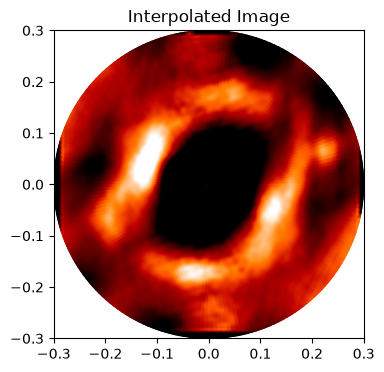

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
xaxis = x_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
yaxis = y_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
ax.pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

# rnge = 0.3
# ax.set_xlim(-rnge,rnge)
# ax.set_ylim(-rnge,rnge)


ax.set_title("Interpolated Image")

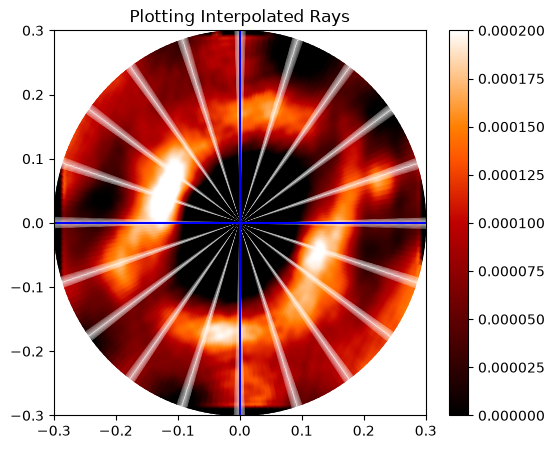

In [24]:
plot_rays(x_grid,y_grid,interp_csm,vmax=0.0002)


# Inverse Abel Transform

In [25]:
from abel import do_abel

In [26]:
from radial import sm

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
radius_2d_arc = np.array([[0.0]*xaxis.shape[1]]*xaxis.shape[0])
#fill pc array of radii
for i in range(xaxis.shape[0]):
        for j in range(xaxis.shape[1]):
            c = (xaxis[i,j])**2+(yaxis[i,j])**2
            radius_2d_arc[i,j] = np.sqrt(c)

            # c = (center_interp-np.abs(xaxis[i,j]))**2+(center_interp-np.abs(yaxis[i,j]))**2
            # radius_2d_arc[i,j] = np.sqrt(c)

In [28]:
x_pc = sm(168,xaxis)*u.pc
y_pc = sm(168,yaxis)*u.pc

In [29]:
radius_2d_pc = sm(168,radius_2d_arc)*u.pc

Text(0, 0.5, '$\\Delta$ Dec (arc)')

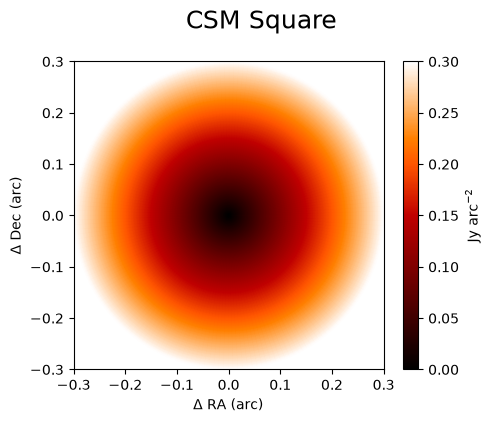

In [30]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

# xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
# yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis,yaxis,radius_2d_arc, cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# ax.set_xlim(minn, maxx)
# ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

Text(0, 0.5, '$\\Delta$ (pc))')

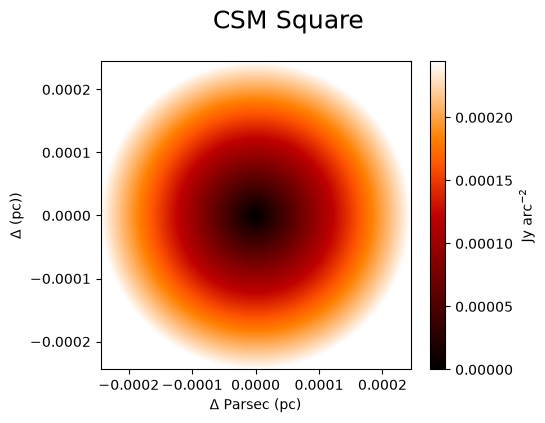

In [31]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

# xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
# yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(x_pc,y_pc,radius_2d_pc.value, cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# ax.set_xlim(minn, maxx)
# ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ Parsec (pc)' , size = 10)
ax.set_ylabel(r'$\Delta$ (pc))' , size = 10)

In [32]:
def do_abel_2(F_arr,s,med):
    '''
    F = radial profile of surface density
    s = radii corresponding with radial profile
    med = background median- sets all neg values in F array to bkg median
    '''
    #print(F_arr)
    integrands = np.zeros(len(s))
    med = med/10
    F = F_arr.copy() # copy density array to prevent overwriting
    F[F<0] = med/100 # turn negative values into background median
    dF_ds = np.gradient(F,s) 
    #dF_ds = dF_ds[~np.isnan(dF_ds)] #this likely only works for this data bc it 
    #s = s[:len(dF_ds)] # only cuts off nans if theyre all at the end of image
    f_r = np.zeros(len(s))
    r_arr = np.zeros(len(s))
    
    for i in range(len(s)-1):
        
        r = (s[i]+s[i+1])/2
        r_arr[i] = r

        
        #print(1/ np.sqrt(s[s>r]**2-r**2))
        integ = np.trapezoid(dF_ds[i+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])
        

        f_r[i]= (-1/np.pi)* integ # integrate from r to highest radial value


    return f_r

In [33]:
csm_abel = []
r_arr = np.zeros(len(interp_csm[i,:]))
row = np.zeros(len(interp_csm[i,:]))
radius_abel_arc = []
x_abel_arc = [] # x data assocated w abel transformed data
y_abel_arc = []
m = 0
all_integrands = []
for i in range(len(interp_csm[:,0])):
    #print('i',i)
    row = np.zeros(len(interp_csm[i,:]))

    row = do_abel_2(interp_csm[i,:],(radius_2d_pc[i,:].to(u.cm)).value,8.7055651*10**-8)


    csm_abel.append(row)


In [34]:
csm_abel = np.array(csm_abel)

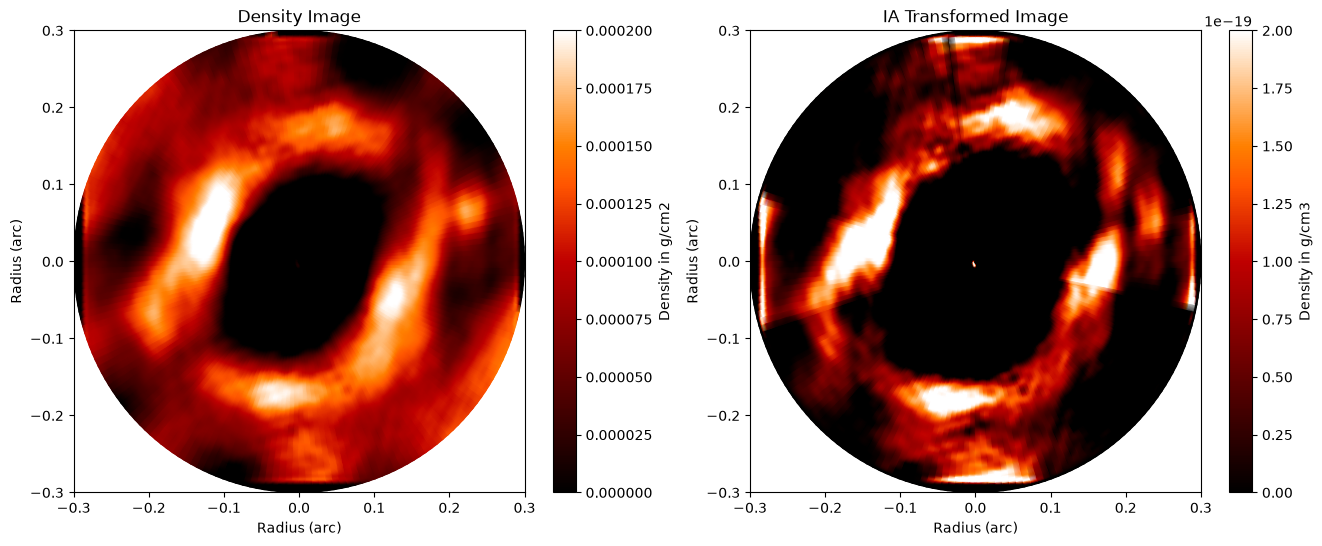

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))

im0 = ax[0].pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

rnge = 0.3
ax[0].set_xlim(-rnge,rnge)
ax[0].set_ylim(-rnge,rnge)
ax[0].set_xlabel("Radius (arc)")
ax[0].set_ylabel("Radius (arc)")

ax[0].set_title("Density Image")
fig.colorbar(im0,label = "Density in g/cm2")

### abel image

im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 2e-19)

ax[1].set_xlim(-rnge,rnge)
ax[1].set_ylim(-rnge,rnge)
ax[1].set_xlabel("Radius (arc)")
ax[1].set_ylabel("Radius (arc)")


ax[1].set_title("IA Transformed Image")
fig.colorbar(im1,label = "Density in g/cm3")